# Debug: Simulator Step-by-Step

Check every stage of the simulation to find where it fails.

In [1]:
import os
os.environ['pRT_input_data_path'] = '/media/mvasist/Elements/PhDprojects/scratch/input_data_v2.4.9/input_data'

import sys
sys.path.insert(0, '/home/mvasist/Documents/SBI4atmret')

import yaml
import torch
import numpy as np
from pathlib import Path

from sbi4atmret.config.configs import BaseConfig
from sbi4atmret.datasets.theta_mapper.thetamapperbase import BaseThetaMapper

## 1. Load config and build components

In [2]:
config_path = '/home/mvasist/Documents/SBI4atmret/experiments/config_MiriGeminiHST_cloudfree.yaml'
with open(config_path) as f:
    config = BaseConfig(**yaml.safe_load(f))

print(f"Params: {config.get_no_of_params()}")
print(f"Names: {config.get_parameter_names()}")

Params: 26
Names: ['R_pl', 'mass', 'T_bottom', 'temp_node_1', 'temp_node_2', 'temp_node_3', 'temp_node_4', 'temp_node_5', 'temp_node_6', 'temp_node_7', 'temp_node_8', 'temp_node_9', 'H2O_mol_scale', 'CO2_mol_scale', 'CO_mol_scale', 'CH4_mol_scale', 'NH3_mol_scale', 'PH3_mol_scale', 'H2S_mol_scale', '15NH3_mol_scale', 'HCN_mol_scale', 'TiO_mol_scale', 'VO_mol_scale', 'bfactor_noise_gemini', 'bfactor_noise_hst', 'bfactor_noise_miri']


In [3]:
# Build prior
prior = config.build_prior()
print(f"Prior type: {type(prior)}")

# Sample one
theta_sample = prior.sample((1,))
print(f"Sample shape: {theta_sample.shape}")
print(f"Sample: {theta_sample}")

Prior type: <class 'sbi4atmret.priors.BoxUniform'>
Sample shape: torch.Size([1, 26])
Sample: tensor([[ 1.2453e+00,  7.1930e+00,  3.6826e+03,  8.4495e-01,  2.9547e-01,
          8.6721e-01,  2.3956e-01,  7.5951e-01,  4.7081e-01,  5.4845e-01,
          9.4708e-01,  8.7706e-01, -4.8766e+00, -1.8922e+00, -5.3702e+00,
         -6.0601e+00, -7.8544e+00, -3.7425e+00, -5.6870e+00, -6.8506e+00,
         -7.6801e+00, -5.7977e+00, -9.1221e+00, -8.2717e+00, -1.1752e+01,
         -1.3410e+01]])


In [4]:
# Build simulators
simulators = config.build_simulators()
print(f"Simulators: {list(simulators.keys())}")

for name, sim in simulators.items():
    print(f"  {name}: {len(sim.names)} params, wavelength [{sim.a}, {sim.b}]")
    print(f"    names: {sim.names}")

Simulators: ['cloudfree_miri', 'cloudfree_hst', 'cloudfree_gemini']
  cloudfree_miri: 24 params, wavelength [4.9, 19]
    names: ['R_pl', 'mass', 'T_bottom', 'temp_node_1', 'temp_node_2', 'temp_node_3', 'temp_node_4', 'temp_node_5', 'temp_node_6', 'temp_node_7', 'temp_node_8', 'temp_node_9', 'H2O_mol_scale', 'CO2_mol_scale', 'CO_mol_scale', 'CH4_mol_scale', 'NH3_mol_scale', 'PH3_mol_scale', 'H2S_mol_scale', '15NH3_mol_scale', 'HCN_mol_scale', 'TiO_mol_scale', 'VO_mol_scale', 'bfactor_noise_miri']
  cloudfree_hst: 26 params, wavelength [0.98, 2.2]
    names: ['R_pl', 'mass', 'T_bottom', 'temp_node_1', 'temp_node_2', 'temp_node_3', 'temp_node_4', 'temp_node_5', 'temp_node_6', 'temp_node_7', 'temp_node_8', 'temp_node_9', 'H2O_mol_scale', 'CO2_mol_scale', 'CO_mol_scale', 'CH4_mol_scale', 'NH3_mol_scale', 'PH3_mol_scale', 'H2S_mol_scale', '15NH3_mol_scale', 'HCN_mol_scale', 'TiO_mol_scale', 'VO_mol_scale', 'mixture_fraction', 'Cushing_scale_factor_h', 'bfactor_noise_hst']
  cloudfree_gemini

## 2. Build theta mapper and split

In [5]:
class _MinimalDomain:
    def __init__(self, simulator_dict):
        self.simulator_dict = simulator_dict

theta_mapper = BaseThetaMapper(
    domain=_MinimalDomain(simulators),
    posterior_param_names=config.get_parameter_names(),
)

print(f"Mapper: {theta_mapper.n_total} merged params")
print(f"Simulator names: {theta_mapper.simulator_names}")
print()

for sim_name in theta_mapper.simulator_names:
    print(f"{sim_name}:")
    print(f"  sim_i indices (merged → sim): {theta_mapper.indices['sim_i'][sim_name]}")
    print(f"  sim_j indices (sim positions): {theta_mapper.indices['sim_j'][sim_name]}")
    print()

Mapper: 26 merged params
Simulator names: ['cloudfree_gemini', 'cloudfree_hst', 'cloudfree_miri']

cloudfree_gemini:
  sim_i indices (merged → sim): tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23])
  sim_j indices (sim positions): tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 25])

cloudfree_hst:
  sim_i indices (merged → sim): tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 24])
  sim_j indices (sim positions): tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 25])

cloudfree_miri:
  sim_i indices (merged → sim): tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 25])
  sim_j indices (sim positions): tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18

In [6]:
# Sample a batch from prior and split
theta_merged = prior.sample((5,))
print(f"Merged theta shape: {theta_merged.shape}")
print(f"Merged theta[0]: {theta_merged[0]}")

theta_dict = theta_mapper.split_theta(theta_merged)
print()
for sim_name, theta_inst in theta_dict.items():
    print(f"{sim_name}: shape={theta_inst.shape}")
    print(f"  theta[0]: {theta_inst[0]}")
    print()

Merged theta shape: torch.Size([5, 26])
Merged theta[0]: tensor([ 2.4642e+00,  6.7457e+00,  4.3104e+03,  6.7622e-01,  7.8789e-01,
         4.5824e-01,  7.1054e-01,  6.9258e-01,  9.7710e-01,  6.0076e-01,
         4.2373e-01,  3.5264e-01, -1.9362e-01, -7.5571e-01, -4.6134e+00,
        -1.5830e+00, -8.7484e+00, -5.6696e+00, -3.8175e+00, -9.6989e+00,
        -8.4559e-01, -9.0473e-01, -2.2108e+00, -1.4642e+01, -1.3165e+01,
        -1.4474e+01])

cloudfree_gemini: shape=torch.Size([5, 26])
  theta[0]: tensor([ 2.4642e+00,  6.7457e+00,  4.3104e+03,  6.7622e-01,  7.8789e-01,
         4.5824e-01,  7.1054e-01,  6.9258e-01,  9.7710e-01,  6.0076e-01,
         4.2373e-01,  3.5264e-01, -1.9362e-01, -7.5571e-01, -4.6134e+00,
        -1.5830e+00, -8.7484e+00, -5.6696e+00, -3.8175e+00, -9.6989e+00,
        -8.4559e-01, -9.0473e-01, -2.2108e+00,  0.0000e+00,  0.0000e+00,
        -1.4642e+01])

cloudfree_hst: shape=torch.Size([5, 26])
  theta[0]: tensor([ 2.4642e+00,  6.7457e+00,  4.3104e+03,  6.7622e-01

## 3. Test single simulator call

In [7]:
# Pick one simulator
sim_name = list(simulators.keys())[0]
simulator = simulators[sim_name]
theta_inst = theta_dict[sim_name]

print(f"Testing {sim_name}")
print(f"  theta shape: {theta_inst[0].shape}")
print(f"  theta values: {theta_inst[0].numpy()}")
print(f"  simulator expects {len(simulator.names)} params: {simulator.names}")

Testing cloudfree_miri
  theta shape: torch.Size([24])
  theta values: [ 2.4641721e+00  6.7457037e+00  4.3103706e+03  6.7622286e-01
  7.8789461e-01  4.5823890e-01  7.1054411e-01  6.9257659e-01
  9.7710383e-01  6.0076290e-01  4.2373478e-01  3.5264301e-01
 -1.9361877e-01 -7.5571156e-01 -4.6134448e+00 -1.5829983e+00
 -8.7483730e+00 -5.6696343e+00 -3.8175039e+00 -9.6989241e+00
 -8.4559059e-01 -9.0472698e-01 -2.2107863e+00 -1.4473650e+01]
  simulator expects 24 params: ['R_pl', 'mass', 'T_bottom', 'temp_node_1', 'temp_node_2', 'temp_node_3', 'temp_node_4', 'temp_node_5', 'temp_node_6', 'temp_node_7', 'temp_node_8', 'temp_node_9', 'H2O_mol_scale', 'CO2_mol_scale', 'CO_mol_scale', 'CH4_mol_scale', 'NH3_mol_scale', 'PH3_mol_scale', 'H2S_mol_scale', '15NH3_mol_scale', 'HCN_mol_scale', 'TiO_mol_scale', 'VO_mol_scale', 'bfactor_noise_miri']


In [8]:
# Try calling the simulator directly
theta_i = theta_inst[0].numpy()
print(f"Calling simulator with theta of shape {theta_i.shape}")
print(f"theta values: {theta_i}")

try:
    output = simulator(theta_i)
    print(f"\nSUCCESS!")
    print(f"  spectrum shape: {output.spectrum.shape}")
    print(f"  wavelength shape: {output.wavelength.shape}")
    print(f"  any NaN in spectrum: {np.any(np.isnan(output.spectrum))}")
    print(f"  any Inf in spectrum: {np.any(np.isinf(output.spectrum))}")
    print(f"  spectrum range: [{output.spectrum.min():.2e}, {output.spectrum.max():.2e}]")
except Exception as e:
    print(f"\nFAILED: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

Calling simulator with theta of shape (24,)
theta values: [ 2.4641721e+00  6.7457037e+00  4.3103706e+03  6.7622286e-01
  7.8789461e-01  4.5823890e-01  7.1054411e-01  6.9257659e-01
  9.7710383e-01  6.0076290e-01  4.2373478e-01  3.5264301e-01
 -1.9361877e-01 -7.5571156e-01 -4.6134448e+00 -1.5829983e+00
 -8.7483730e+00 -5.6696343e+00 -3.8175039e+00 -9.6989241e+00
 -8.4559059e-01 -9.0472698e-01 -2.2107863e+00 -1.4473650e+01]

SUCCESS!
  spectrum shape: (1355,)

FAILED: AttributeError: 'NoneType' object has no attribute 'shape'


Traceback (most recent call last):
  File "/tmp/ipykernel_27310/589873624.py", line 10, in <module>
    print(f"  wavelength shape: {output.wavelength.shape}")
AttributeError: 'NoneType' object has no attribute 'shape'


Spectrum is None or contains NaN — simulation failed for this sample


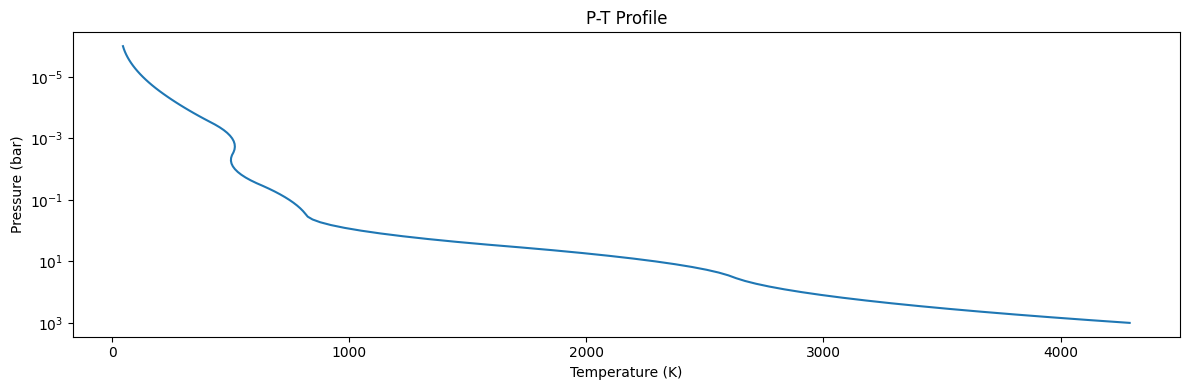

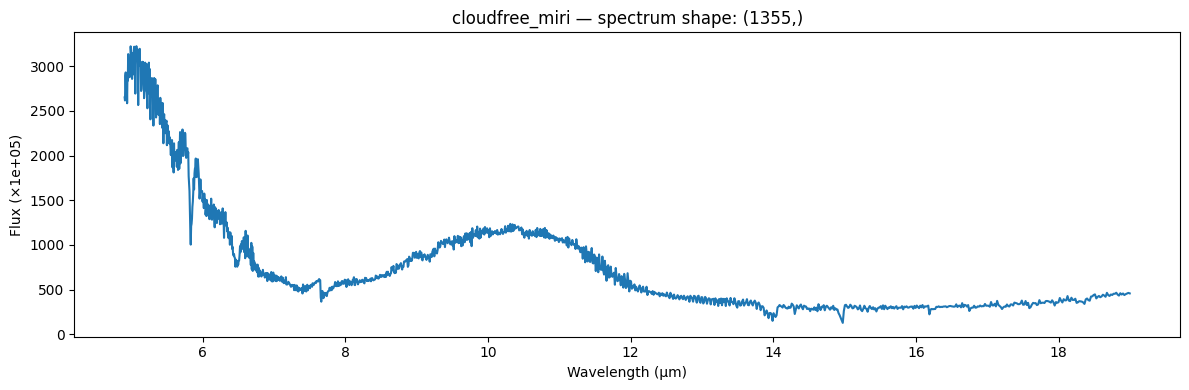

Wavelength range: [4.90, 19.00] μm
Flux range: [1.27e+02, 3.23e+03]


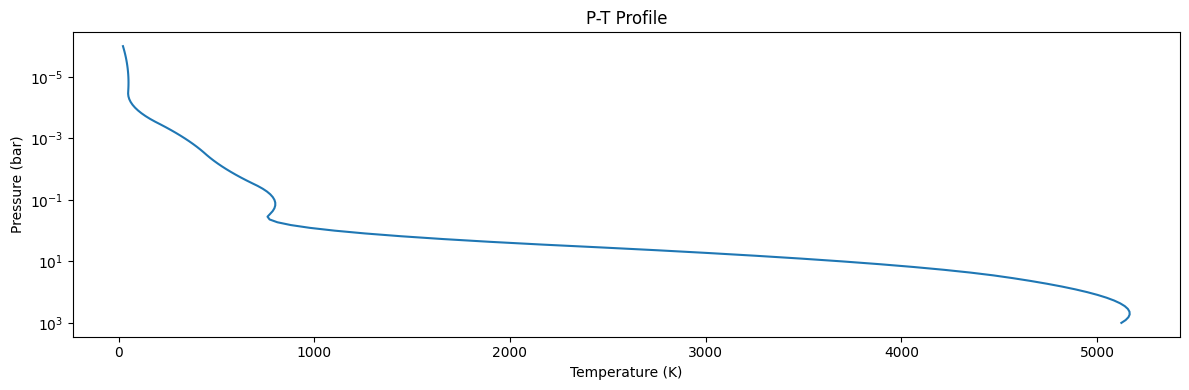

Spectrum is None or contains NaN — simulation failed for this sample


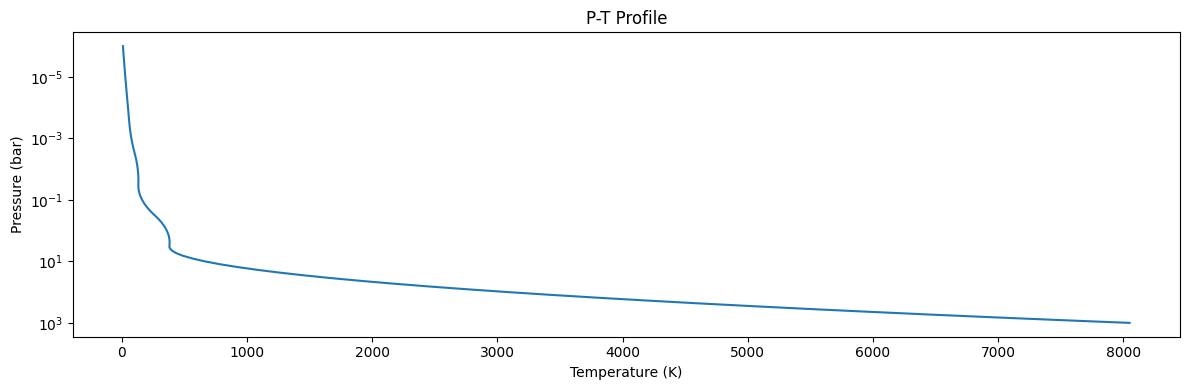

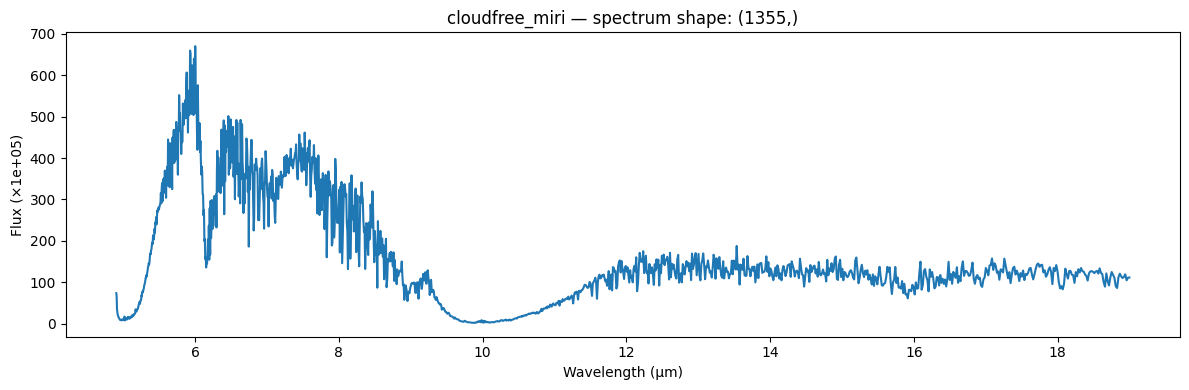

Wavelength range: [4.90, 19.00] μm
Flux range: [1.69e+00, 6.70e+02]


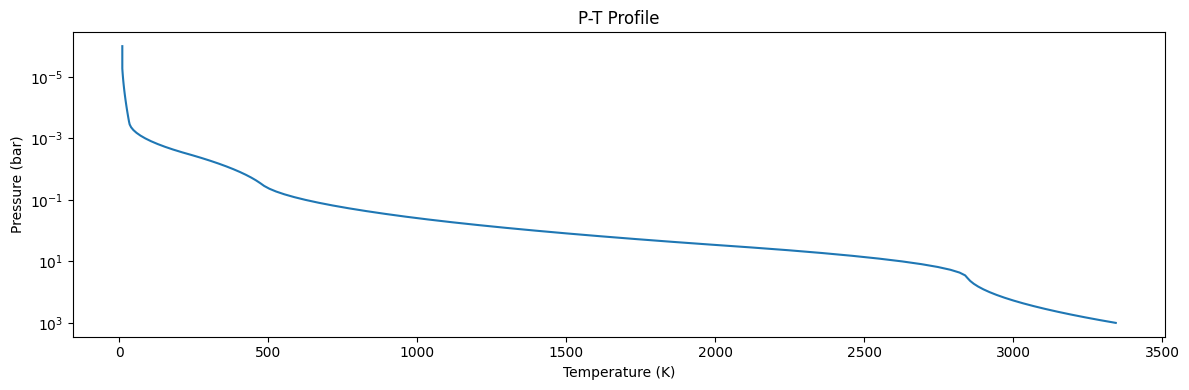

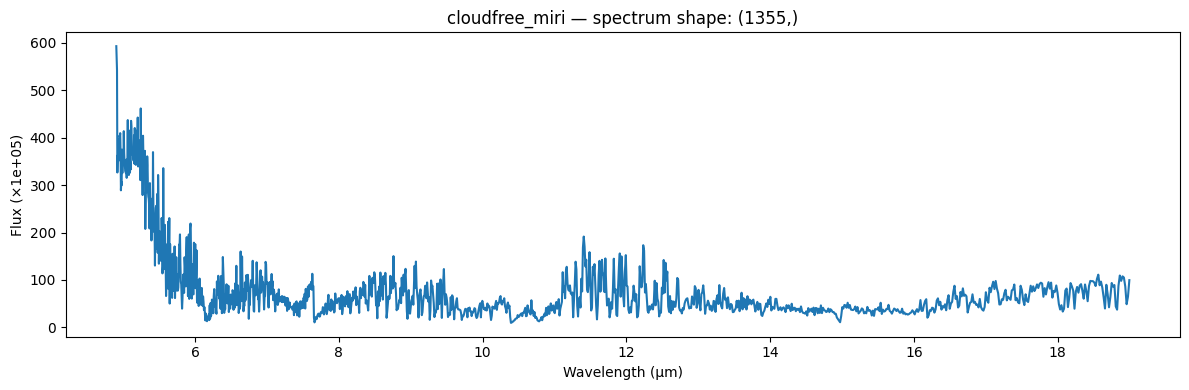

Wavelength range: [4.90, 19.00] μm
Flux range: [9.43e+00, 5.93e+02]


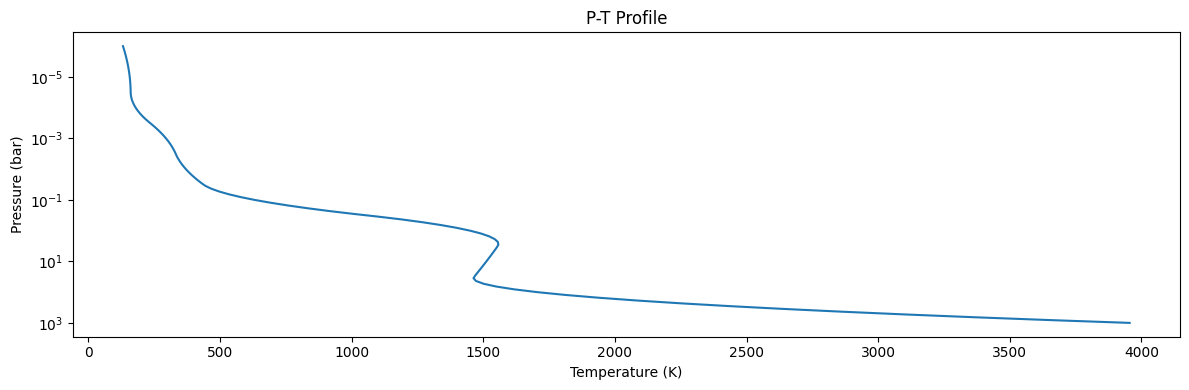

Success: 3/5
Failures:
  Sample 0: spectrum is None or has NaN
  Sample 2: spectrum is None or has NaN


In [9]:
# Try multiple samples to see failure rate
n_tries = 5
successes = 0
failures = []

for i in range(n_tries):
    theta_i = theta_inst[i].numpy()
    try:
        output = simulator(theta_i)
        if output.spectrum is not None and not np.any(np.isnan(output.spectrum)):
            successes += 1
        else:
            failures.append(f"Sample {i}: spectrum is None or has NaN")
    except Exception as e:
        failures.append(f"Sample {i}: {type(e).__name__}: {e}")


    import matplotlib.pyplot as plt

    # Spectrum
    if output.spectrum is not None and not np.any(np.isnan(output.spectrum)):
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(output.wavelength, output.spectrum)
        ax.set_xlabel("Wavelength (μm)")
        ax.set_ylabel(f"Flux (×{simulator.scale:.0e})")
        ax.set_title(f"{sim_name} — spectrum shape: {output.spectrum.shape}")
        plt.tight_layout()
        plt.show()
        
        print(f"Wavelength range: [{output.wavelength.min():.2f}, {output.wavelength.max():.2f}] μm")
        print(f"Flux range: [{output.spectrum.min():.2e}, {output.spectrum.max():.2e}]")
    else:
        print("Spectrum is None or contains NaN — simulation failed for this sample")


    
    # PT profile
    if output.temperatures is not None and output.pressures is not None:
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(output.temperatures, output.pressures)
        ax.set_yscale("log")
        ax.invert_yaxis()
        ax.set_xlabel("Temperature (K)")
        ax.set_ylabel("Pressure (bar)")
        ax.set_title("P-T Profile")
    else:
        ax.text(0.5, 0.5, "No PT data", ha='center', va='center', transform=ax2.transAxes)

    plt.tight_layout()
    plt.show()



print(f"Success: {successes}/{n_tries}")
if failures:
    print("Failures:")
    for f in failures:
        print(f"  {f}")

In [10]:
# Try calling the simulator directly
theta_i = theta_inst[0].numpy()
print(f"Calling simulator with theta of shape {theta_i.shape}")
print(f"theta values: {theta_i}")

try:
    output = simulator(theta_i)
    print(f"\nSUCCESS!")
    print(f"  spectrum shape: {output.spectrum.shape}")
    print(f"  wavelength shape: {output.wavelength.shape}")
    print(f"  any NaN in spectrum: {np.any(np.isnan(output.spectrum))}")
    print(f"  any Inf in spectrum: {np.any(np.isinf(output.spectrum))}")
    print(f"  spectrum range: [{output.spectrum.min():.2e}, {output.spectrum.max():.2e}]")
except Exception as e:
    print(f"\nFAILED: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

Calling simulator with theta of shape (24,)
theta values: [ 2.4641721e+00  6.7457037e+00  4.3103706e+03  6.7622286e-01
  7.8789461e-01  4.5823890e-01  7.1054411e-01  6.9257659e-01
  9.7710383e-01  6.0076290e-01  4.2373478e-01  3.5264301e-01
 -1.9361877e-01 -7.5571156e-01 -4.6134448e+00 -1.5829983e+00
 -8.7483730e+00 -5.6696343e+00 -3.8175039e+00 -9.6989241e+00
 -8.4559059e-01 -9.0472698e-01 -2.2107863e+00 -1.4473650e+01]

SUCCESS!
  spectrum shape: (1355,)

FAILED: AttributeError: 'NoneType' object has no attribute 'shape'


Traceback (most recent call last):
  File "/tmp/ipykernel_27310/589873624.py", line 10, in <module>
    print(f"  wavelength shape: {output.wavelength.shape}")
AttributeError: 'NoneType' object has no attribute 'shape'


## 4. Check the split_theta mapping

Is the issue that split_theta puts zeros where the simulator expects real values?

In [11]:
# Check if split_theta produces zeros (unfilled positions)
for sim_name, theta_inst in theta_dict.items():
    zero_cols = (theta_inst == 0).all(dim=0)
    if zero_cols.any():
        zero_indices = torch.where(zero_cols)[0].tolist()
        sim = simulators[sim_name]
        zero_names = [sim.names[j] for j in zero_indices if j < len(sim.names)]
        print(f"{sim_name}: ZEROS in columns {zero_indices} → params {zero_names}")
    else:
        print(f"{sim_name}: No zero columns ✓")

cloudfree_gemini: ZEROS in columns [23, 24] → params ['mixture_fraction', 'Cushing_scale_factor_g']
cloudfree_hst: ZEROS in columns [23, 24] → params ['mixture_fraction', 'Cushing_scale_factor_h']
cloudfree_miri: No zero columns ✓


## 5. Test with known good values

In [12]:
# Try with a hand-crafted theta that should work
# (typical brown dwarf atmosphere)
sim_name = 'cloudfree_miri'
sim = simulators[sim_name]

print(f"Simulator expects: {sim.names}")
print(f"Number of params: {len(sim.names)}")

# Build a reasonable theta manually
# R_pl=1.1, mass=15, T_bottom=5700, tnodes~0.5, abundances~-5, b=-10
# Adjust based on what sim.names shows

Simulator expects: ['R_pl', 'mass', 'T_bottom', 'temp_node_1', 'temp_node_2', 'temp_node_3', 'temp_node_4', 'temp_node_5', 'temp_node_6', 'temp_node_7', 'temp_node_8', 'temp_node_9', 'H2O_mol_scale', 'CO2_mol_scale', 'CO_mol_scale', 'CH4_mol_scale', 'NH3_mol_scale', 'PH3_mol_scale', 'H2S_mol_scale', '15NH3_mol_scale', 'HCN_mol_scale', 'TiO_mol_scale', 'VO_mol_scale', 'bfactor_noise_miri']
Number of params: 24


## 6. Plot spectrum

In [13]:
import matplotlib.pyplot as plt

# Run simulator on first sample
theta_i = theta_inst[0].numpy()
output = simulator(theta_i)

if output.spectrum is not None and not np.any(np.isnan(output.spectrum)):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(output.wavelength, output.spectrum)
    ax.set_xlabel("Wavelength (μm)")
    ax.set_ylabel(f"Flux (×{simulator.scale:.0e})")
    ax.set_title(f"{sim_name} — spectrum shape: {output.spectrum.shape}")
    plt.tight_layout()
    plt.show()
    
    print(f"Wavelength range: [{output.wavelength.min():.2f}, {output.wavelength.max():.2f}] μm")
    print(f"Flux range: [{output.spectrum.min():.2e}, {output.spectrum.max():.2e}]")
else:
    print("Spectrum is None or contains NaN — simulation failed for this sample")


Spectrum is None or contains NaN — simulation failed for this sample


## 7. Plot PT profile

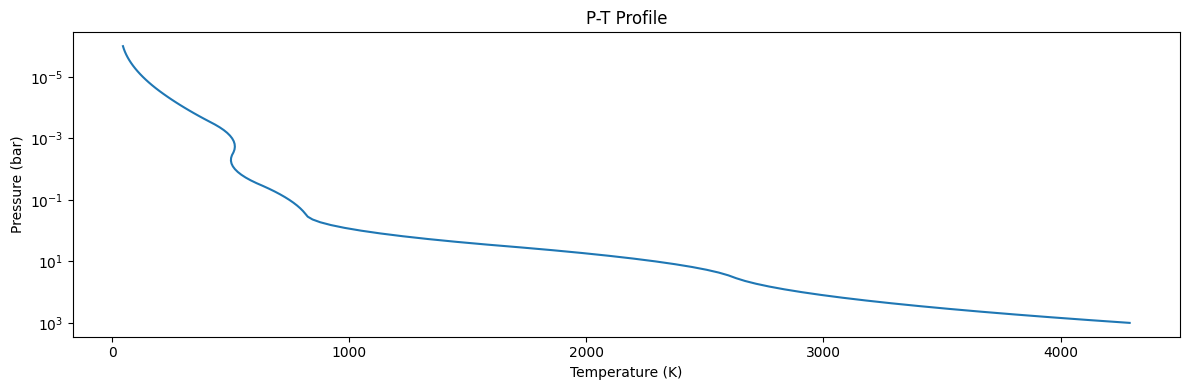

In [14]:
# PT profile
if output.temperatures is not None and output.pressures is not None:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(output.temperatures, output.pressures)
    ax.set_yscale("log")
    ax.invert_yaxis()
    ax.set_xlabel("Temperature (K)")
    ax.set_ylabel("Pressure (bar)")
    ax.set_title("P-T Profile")
else:
    ax.text(0.5, 0.5, "No PT data", ha='center', va='center', transform=ax2.transAxes)

plt.tight_layout()
plt.show()